Mounted at /content/drive
generating advection dataset with wang setup (BC: s(0,t)=sin(pi/2 t))
solver output range: min=0.0000, max=1.0000
any NaN: False, any Inf: False


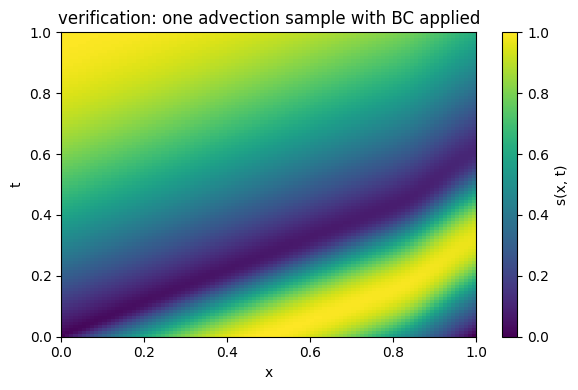


model 1/3: PINN


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


pinn step      0 | phys 3.586e-03 | ic 3.690e-01 | bc 3.718e-01
pinn step  10000 | phys 1.421e-03 | ic 5.933e-05 | bc 3.203e-05
pinn step  20000 | phys 2.970e-04 | ic 1.019e-05 | bc 1.131e-05
pinn step  30000 | phys 1.179e-04 | ic 4.674e-06 | bc 1.059e-06
pinn step  40000 | phys 1.085e-04 | ic 2.643e-06 | bc 2.167e-06
pinn step  50000 | phys 7.545e-05 | ic 9.755e-07 | bc 7.854e-07
pinn step  60000 | phys 5.026e-05 | ic 8.425e-07 | bc 1.379e-06
pinn step  70000 | phys 4.112e-05 | ic 5.029e-07 | bc 5.690e-07
pinn step  80000 | phys 4.423e-05 | ic 6.426e-07 | bc 8.350e-07
PINN rel L2 error: 2.2839%

model 2/3: DeepONet
don step      0 | data 2.713e-01
don step  10000 | data 7.180e-04
don step  20000 | data 2.745e-04
don step  30000 | data 1.696e-04
don step  40000 | data 1.271e-04
don step  50000 | data 1.044e-04
don step  60000 | data 9.590e-05
don step  70000 | data 8.626e-05
don step  80000 | data 8.405e-05
DeepONet mean rel L2: 1.1705% +/- 0.1721%

model 3/3: PI-DeepONet
pi  step     

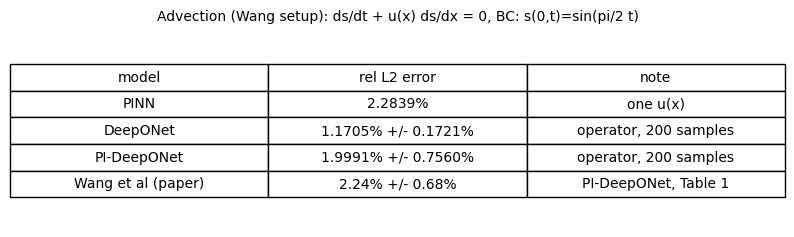

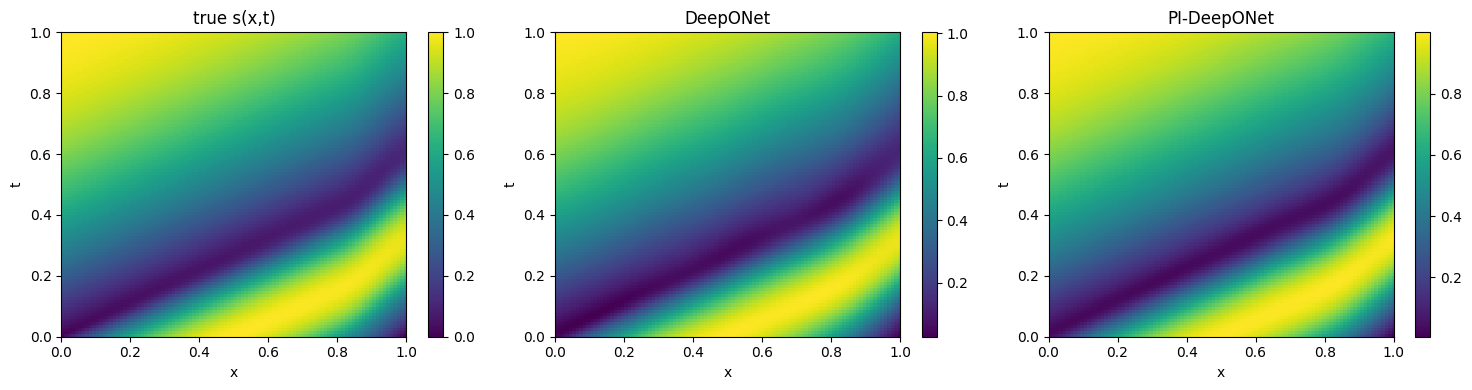

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("switch colab runtime to GPU first")
device = "cuda"

N_TRAIN = 1000
N_TEST = 200
M_SENSORS = 40
P_POINTS = 100
GRF_LENGTH_SCALE = 0.2

PINN_ITERS = 80000
DON_ITERS = 80000
PI_ITERS = 80000
LR_INIT = 1e-3
LR_DECAY_STEPS = 5000
LR_DECAY_RATE = 0.9
LAMBDA_PHYS = 1.0
LAMBDA_IC = 20.0
LAMBDA_BC = 20.0
BATCH = 5000
N_PINN_COLLOC = 1000
WIDTH = 50
DEPTH = 5

NX = 100
CFL_SAFETY = 0.4

RUN_TAG = "advection_v3_wang_setup"

def sample_grf(n_samples, n_points, length_scale):
    x = np.linspace(0, 1, n_points)
    xi, xj = np.meshgrid(x, x)
    K = np.exp(-0.5 * ((xi - xj) / length_scale) ** 2) + 1e-10 * np.eye(n_points)
    L = np.linalg.cholesky(K)
    z = np.random.randn(n_samples, n_points)
    return z @ L.T

def solve_advection_upwind(u_at_sensors, nx=NX):
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]
    u_x = np.interp(x, np.linspace(0, 1, len(u_at_sensors)), u_at_sensors)
    u_x = np.clip(u_x, 0.5, 2.0)

    u_max = u_x.max()
    dt = CFL_SAFETY * dx / u_max
    nt = int(np.ceil(1.0 / dt)) + 1
    dt = 1.0 / (nt - 1)

    s = np.zeros((nt, nx), dtype=np.float32)
    s[0] = np.sin(np.pi * x)

    for n in range(nt - 1):
        t_next = (n + 1) * dt
        s[n + 1, 1:] = s[n, 1:] - u_x[1:] * dt / dx * (s[n, 1:] - s[n, :-1])
        s[n + 1, 0] = np.sin(np.pi / 2 * t_next)

        if not np.isfinite(s[n + 1]).all():
            raise RuntimeError(f"solver blew up at step {n+1}, u_max={u_max:.3f}")

    t = np.linspace(0, 1, nt)
    nt_out = 100
    t_out = np.linspace(0, 1, nt_out)
    s_out = np.zeros((nt_out, nx), dtype=np.float32)
    for i in range(nx):
        s_out[:, i] = np.interp(t_out, t, s[:, i])

    return x, t_out, s_out

x_sensors = np.linspace(0, 1, M_SENSORS)

def make_dataset(n_samples):
    u_raw = sample_grf(n_samples, M_SENSORS, GRF_LENGTH_SCALE).astype(np.float32)
    u_at_sensors = (u_raw - u_raw.min(axis=1, keepdims=True) + 1.0).astype(np.float32)
    u_at_sensors = np.clip(u_at_sensors, 0.5, 2.0)

    xt_query = np.random.rand(n_samples, P_POINTS, 2).astype(np.float32)
    s_query = np.zeros((n_samples, P_POINTS), dtype=np.float32)
    s_full_list = []
    for i in range(n_samples):
        x_grid, t_grid, s_grid = solve_advection_upwind(u_at_sensors[i])
        s_full_list.append(s_grid)
        for p in range(P_POINTS):
            xi_q, ti_q = xt_query[i, p]
            ix = int(np.clip(xi_q * (len(x_grid) - 1), 0, len(x_grid) - 2))
            it = int(np.clip(ti_q * (len(t_grid) - 1), 0, len(t_grid) - 2))
            s_query[i, p] = s_grid[it, ix]
    return u_at_sensors, xt_query, s_query, np.array(s_full_list)

print("generating advection dataset with wang setup (BC: s(0,t)=sin(pi/2 t))")
u_train, xt_train, s_train, _ = make_dataset(N_TRAIN)
u_test, xt_test, s_test, s_test_full = make_dataset(N_TEST)

print(f"solver output range: min={s_test_full.min():.4f}, max={s_test_full.max():.4f}")
print(f"any NaN: {np.isnan(s_test_full).any()}, any Inf: {np.isinf(s_test_full).any()}")

plt.figure(figsize=(6, 4))
plt.imshow(s_test_full[0], aspect="auto", origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
plt.colorbar(label="s(x, t)")
plt.xlabel("x"); plt.ylabel("t")
plt.title("verification: one advection sample with BC applied")
plt.tight_layout()
plt.savefig(f"{RUN_TAG}_simulation_check.png", dpi=200, bbox_inches="tight")
plt.show()

def mlp(sizes, act):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(torch.nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(act())
    return torch.nn.Sequential(*layers)

class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp([2] + [WIDTH] * DEPTH + [1], torch.nn.Tanh)
    def forward(self, xt):
        return self.net(xt)

class DeepONet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.branch = mlp([M_SENSORS] + [WIDTH] * DEPTH, torch.nn.Tanh)
        self.trunk = mlp([2] + [WIDTH] * DEPTH, torch.nn.Tanh)
        self.bias = torch.nn.Parameter(torch.zeros(1))
    def forward(self, u, xt):
        return (self.branch(u) * self.trunk(xt)).sum(dim=1, keepdim=True) + self.bias

PIDeepONet = DeepONet

def rel_l2(pred, true):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-10)

def u_interp_np_batch(x_query_np, u_vals_np):
    idx_left = np.clip(np.searchsorted(x_sensors, x_query_np) - 1, 0, M_SENSORS - 2)
    x_left = x_sensors[idx_left]
    x_right = x_sensors[idx_left + 1]
    alpha = ((x_query_np - x_left) / (x_right - x_left)).astype(np.float32)
    if u_vals_np.ndim == 1:
        return u_vals_np[idx_left] + alpha * (u_vals_np[idx_left + 1] - u_vals_np[idx_left])
    else:
        n = len(x_query_np)
        u_left = u_vals_np[np.arange(n), idx_left]
        u_right = u_vals_np[np.arange(n), idx_left + 1]
        return u_left + alpha * (u_right - u_left)

print("\nmodel 1/3: PINN")
u_pinn = u_test[0]

pinn_net = PINN().to(device)
pinn_opt = torch.optim.Adam(pinn_net.parameters(), lr=LR_INIT)
pinn_sched = torch.optim.lr_scheduler.StepLR(pinn_opt, step_size=LR_DECAY_STEPS, gamma=LR_DECAY_RATE)

for step in range(PINN_ITERS + 1):
    xt_c = torch.rand(N_PINN_COLLOC, 2, device=device, requires_grad=True)
    s_pred = pinn_net(xt_c)
    grads = torch.autograd.grad(s_pred, xt_c, grad_outputs=torch.ones_like(s_pred), create_graph=True)[0]
    ds_dx = grads[:, 0:1]
    ds_dt = grads[:, 1:2]
    x_np = xt_c[:, 0].detach().cpu().numpy()
    u_at_x = torch.tensor(u_interp_np_batch(x_np, u_pinn).reshape(-1, 1), device=device)
    loss_phys = ((ds_dt + u_at_x * ds_dx) ** 2).mean()

    x_ic = torch.rand(200, 1, device=device)
    xt_ic = torch.cat([x_ic, torch.zeros_like(x_ic)], dim=1)
    s_ic_pred = pinn_net(xt_ic)
    loss_ic = ((s_ic_pred - torch.sin(np.pi * x_ic)) ** 2).mean()

    t_bc = torch.rand(200, 1, device=device)
    xt_bc = torch.cat([torch.zeros_like(t_bc), t_bc], dim=1)
    s_bc_pred = pinn_net(xt_bc)
    loss_bc = ((s_bc_pred - torch.sin(np.pi / 2 * t_bc)) ** 2).mean()

    loss = LAMBDA_PHYS * loss_phys + LAMBDA_IC * loss_ic + LAMBDA_BC * loss_bc
    pinn_opt.zero_grad()
    loss.backward()
    pinn_opt.step()
    pinn_sched.step()

    if step % 10000 == 0:
        print(f"pinn step {step:6d} | phys {loss_phys.item():.3e} | ic {loss_ic.item():.3e} | bc {loss_bc.item():.3e}")

with torch.no_grad():
    xg, tg, s_true_pinn = solve_advection_upwind(u_pinn)
    nx, nt = len(xg), len(tg)
    XX, TT = np.meshgrid(xg, tg)
    xt_eval = torch.tensor(np.stack([XX.flatten(), TT.flatten()], axis=1).astype(np.float32), device=device)
    s_pinn_pred = pinn_net(xt_eval).cpu().numpy().reshape(nt, nx)
pinn_error = rel_l2(s_pinn_pred, s_true_pinn)
print(f"PINN rel L2 error: {pinn_error:.4%}")

print("\nmodel 2/3: DeepONet")
don = DeepONet().to(device)
don_opt = torch.optim.Adam(don.parameters(), lr=LR_INIT)
don_sched = torch.optim.lr_scheduler.StepLR(don_opt, step_size=LR_DECAY_STEPS, gamma=LR_DECAY_RATE)

u_train_t = torch.tensor(u_train.repeat(P_POINTS, 0).reshape(N_TRAIN * P_POINTS, M_SENSORS), device=device)
xt_train_t = torch.tensor(xt_train.reshape(-1, 2), device=device)
s_train_t = torch.tensor(s_train.reshape(-1, 1), device=device)

for step in range(DON_ITERS + 1):
    idx = torch.randint(0, u_train_t.shape[0], (BATCH,))
    pred = don(u_train_t[idx], xt_train_t[idx])
    loss = ((pred - s_train_t[idx]) ** 2).mean()
    don_opt.zero_grad()
    loss.backward()
    don_opt.step()
    don_sched.step()
    if step % 10000 == 0:
        print(f"don step {step:6d} | data {loss.item():.3e}")

with torch.no_grad():
    u_test_t = torch.tensor(u_test, device=device)
    don_preds = np.zeros((N_TEST, len(tg), len(xg)))
    for i in range(N_TEST):
        u_i = u_test_t[i:i+1].repeat(nt * nx, 1)
        xt_i = torch.tensor(np.stack([XX.flatten(), TT.flatten()], axis=1).astype(np.float32), device=device)
        don_preds[i] = don(u_i, xt_i).cpu().numpy().reshape(nt, nx)
don_errors = [rel_l2(don_preds[i], s_test_full[i]) for i in range(N_TEST)]
don_mean = np.mean(don_errors)
don_std = np.std(don_errors)
print(f"DeepONet mean rel L2: {don_mean:.4%} +/- {don_std:.4%}")

print("\nmodel 3/3: PI-DeepONet")
pinet = PIDeepONet().to(device)
pi_opt = torch.optim.Adam(pinet.parameters(), lr=LR_INIT)
pi_sched = torch.optim.lr_scheduler.StepLR(pi_opt, step_size=LR_DECAY_STEPS, gamma=LR_DECAY_RATE)

u_all_train_t = torch.tensor(u_train, device=device)

for step in range(PI_ITERS + 1):
    idx = torch.randint(0, u_train_t.shape[0], (BATCH,))
    pred = pinet(u_train_t[idx], xt_train_t[idx])
    loss_data = ((pred - s_train_t[idx]) ** 2).mean()

    idx_p = torch.randint(0, N_TRAIN, (BATCH,))
    u_p = u_all_train_t[idx_p]
    xt_p = torch.rand(BATCH, 2, device=device, requires_grad=True)
    s_p = pinet(u_p, xt_p)
    grads = torch.autograd.grad(s_p, xt_p, grad_outputs=torch.ones_like(s_p), create_graph=True)[0]
    ds_dx = grads[:, 0:1]
    ds_dt = grads[:, 1:2]
    x_np = xt_p[:, 0].detach().cpu().numpy()
    u_vals_np = u_train[idx_p.cpu().numpy()]
    u_at_x = torch.tensor(u_interp_np_batch(x_np, u_vals_np).reshape(-1, 1), device=device)
    loss_phys = ((ds_dt + u_at_x * ds_dx) ** 2).mean()

    x_ic = torch.rand(BATCH, 1, device=device)
    xt_ic = torch.cat([x_ic, torch.zeros_like(x_ic)], dim=1)
    s_ic_pred = pinet(u_all_train_t[idx_p], xt_ic)
    loss_ic = ((s_ic_pred - torch.sin(np.pi * x_ic)) ** 2).mean()

    t_bc = torch.rand(BATCH, 1, device=device)
    xt_bc = torch.cat([torch.zeros_like(t_bc), t_bc], dim=1)
    s_bc_pred = pinet(u_all_train_t[idx_p], xt_bc)
    loss_bc = ((s_bc_pred - torch.sin(np.pi / 2 * t_bc)) ** 2).mean()

    loss = loss_data + LAMBDA_PHYS * loss_phys + LAMBDA_IC * loss_ic + LAMBDA_BC * loss_bc
    pi_opt.zero_grad()
    loss.backward()
    pi_opt.step()
    pi_sched.step()
    if step % 10000 == 0:
        print(f"pi  step {step:6d} | data {loss_data.item():.3e} | phys {loss_phys.item():.3e} | ic {loss_ic.item():.3e} | bc {loss_bc.item():.3e}")

with torch.no_grad():
    pi_preds = np.zeros((N_TEST, nt, nx))
    for i in range(N_TEST):
        u_i = u_test_t[i:i+1].repeat(nt * nx, 1)
        xt_i = torch.tensor(np.stack([XX.flatten(), TT.flatten()], axis=1).astype(np.float32), device=device)
        pi_preds[i] = pinet(u_i, xt_i).cpu().numpy().reshape(nt, nx)
pi_errors = [rel_l2(pi_preds[i], s_test_full[i]) for i in range(N_TEST)]
pi_mean = np.mean(pi_errors)
pi_std = np.std(pi_errors)
print(f"PI-DeepONet mean rel L2: {pi_mean:.4%} +/- {pi_std:.4%}")

print("\n" + "=" * 70)
print(f"  FINAL METRICS: {RUN_TAG}")
print("=" * 70)
print(f"{'model':<22}{'rel L2 error':<24}{'note':<30}")
print(f"{'PINN':<22}{f'{pinn_error:.4%}':<24}{'one u(x)':<30}")
print(f"{'DeepONet':<22}{f'{don_mean:.4%} +/- {don_std:.4%}':<24}{f'operator, {N_TEST}':<30}")
print(f"{'PI-DeepONet':<22}{f'{pi_mean:.4%} +/- {pi_std:.4%}':<24}{f'operator, {N_TEST}':<30}")
print(f"{'Wang et al reported':<22}{'2.24% +/- 0.68%':<24}{'PI-DeepONet, Table 1':<30}")
print("=" * 70)

rows = [
    ["PINN", f"{pinn_error:.4%}", "one u(x)"],
    ["DeepONet", f"{don_mean:.4%} +/- {don_std:.4%}", f"operator, {N_TEST} samples"],
    ["PI-DeepONet", f"{pi_mean:.4%} +/- {pi_std:.4%}", f"operator, {N_TEST} samples"],
    ["Wang et al (paper)", "2.24% +/- 0.68%", "PI-DeepONet, Table 1"],
]
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=["model", "rel L2 error", "note"], loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.6)
ax.set_title("Advection (Wang setup): ds/dt + u(x) ds/dx = 0, BC: s(0,t)=sin(pi/2 t)", fontsize=10, pad=10)
plt.savefig(f"{RUN_TAG}_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
im0 = axs[0].imshow(s_test_full[0], aspect="auto", origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axs[0].set_title("true s(x,t)"); plt.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(don_preds[0], aspect="auto", origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axs[1].set_title("DeepONet"); plt.colorbar(im1, ax=axs[1])
im2 = axs[2].imshow(pi_preds[0], aspect="auto", origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axs[2].set_title("PI-DeepONet"); plt.colorbar(im2, ax=axs[2])
for ax in axs: ax.set_xlabel("x"); ax.set_ylabel("t")
plt.tight_layout()
plt.savefig(f"{RUN_TAG}_contours.png", dpi=200, bbox_inches="tight")
plt.show()